# Оценки: ОММ, ОМП, ОМС


**Исполнитель (ФИО):** Липунцов Антон Юрьевич

---

Здравствуйте! В этом практикуме вам предстоит познакомиться с численным рассчётом оценок параметров распределения

Задача оценки параметров появляется, когда мы работам с выборкой, о которой мы знаем, что она имеет распределение $F_{\theta}$ (нам известно из какого она семейства распределений) и мы хотим оценить параметр $\theta$ (узнать конкретное распределение)

Существует три основных способа расчета оценок:

1. Методом моментов (ОММ)
2. Методом максимального правдоподобия (ОМП)
3. Методом спейсингов (ОМС)

## Задача 1

Выведите Оценку Методом Моментов аналитически для двух параметров следующих распределений:

1. $R[a,b]$
2. $\text{Г}(\alpha,\beta)$
3. $Beta(a,b)$

**Вопрос:** Какие получились оценки параметров распределений?

Пусть $E$ и $D$ - мат. ожидание и дисперсия.  
1. $R[a,b]$  
   $a = E - \sqrt{3D}$  
   $b = E + \sqrt{3D}$

2. $\text{Г}(\alpha,\beta)$  
   $\alpha = \frac{E^2}{D}$  
   $\beta = \frac{D}{E}$
3. $Beta(a,b)$  
   $a = \frac{E^2(1 - E)}{D} - E$  
   $b = \frac{E(1 - E)^2}{D} - 1 + E$
  




Сгенерируйте выборки из соответствующих распределений, параметры выберите самостоятельно

In [1]:
import numpy as np

N = 1000
a = 2
b = 4

uni_sample = np.random.uniform(a, b, N)
gamma_sample = np.random.gamma(shape=a, scale=b, size=N)
beta_sample = np.random.beta(a, b, size=N)

Посчитайте ОММ для этих распределений по выведенным формулам с помощью выборочных моментов

In [2]:
E = np.mean(uni_sample)
D = np.var(uni_sample)
uni_a = E - np.sqrt(3*D)
uni_b = E + np.sqrt(3*D)
print(f"R a = {uni_a}, b = {uni_b}")

E = np.mean(gamma_sample)
D = np.var(gamma_sample)
gamma_a = E**2/D
gamma_b = D/E
print(f"Gamma a = {gamma_a}, b = {gamma_b}")

E = np.mean(beta_sample)
D = np.var(beta_sample)
beta_a = E**2*(1-E)/D - E
beta_b = E*(1-E)**2/D - 1 + E
print(f"Beta a = {beta_a}, b = {beta_b}")

R a = 2.018048367735264, b = 3.983189691052651
Gamma a = 1.827790383000692, b = 4.4114903935517145
Beta a = 2.0886247415529735, b = 4.061740109888143


**Вопрос:** Насколько отличаются истинные и выборочные моменты?

Не более 2% по модулю

Визуализируйте выборки, добавьте на график истинную плотность распределения и плотность распределения с оцененными параметрами

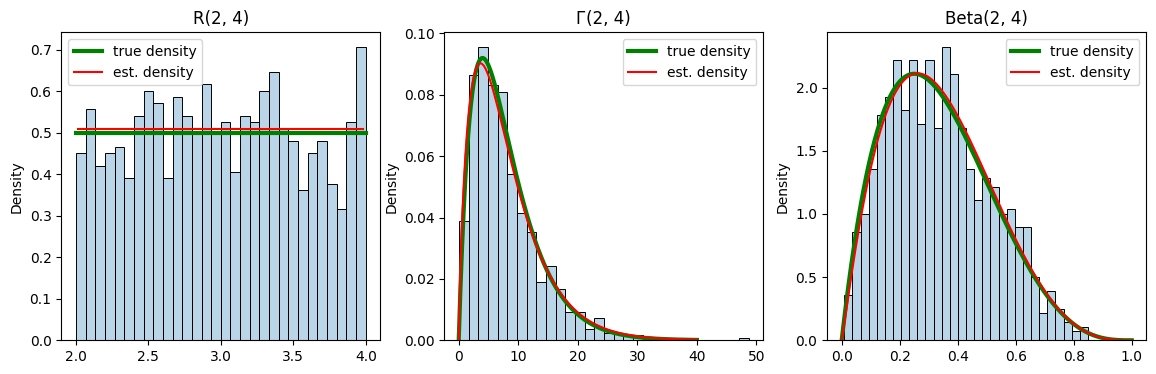

In [3]:
import seaborn as sb
from scipy import stats
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sb.histplot(uni_sample, bins=30, stat='density', alpha=0.3)

x_true = np.linspace(a, b, N)
uni_pdf_true = stats.uniform.pdf(x_true, loc=a, scale=b-a)
x_est = np.linspace(uni_a, uni_b, N)
uni_pdf_est = stats.uniform.pdf(x_est, loc=uni_a, scale=uni_b - uni_a)

plt.plot(x_true, uni_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_est, uni_pdf_est, color="r", label='est. density')
plt.title(f'R({a}, {b})')
plt.legend()


plt.subplot(1, 3, 2)
sb.histplot(gamma_sample, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(0, 40, N)
gamma_pdf_true = stats.gamma.pdf(x_plot, a, scale=b)
gamma_pdf_est = stats.gamma.pdf(x_plot, gamma_a, scale=gamma_b)
plt.plot(x_plot, gamma_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, gamma_pdf_est, color="r", label='est. density')
plt.title(f'Г({a}, {b})')
plt.legend()

plt.subplot(1, 3, 3)
sb.histplot(beta_sample, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(0, 1, N)
beta_pdf_true = stats.beta.pdf(x_plot, a, b)
beta_pdf_est = stats.beta.pdf(x_plot, beta_a, beta_b)
plt.plot(x_plot, beta_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, beta_pdf_est, color="r", label='est. density')
plt.title(f'Beta({a}, {b})')
plt.legend()

**Вопрос:** Насколько оцененная плотность отличается от истинной? Подумайте, почему? Как меняется ОММ от количества элементов выборки?

Отличается не сильно, но не совпадает, так как небольшая неточность в оценке параметра меняет весь график оценочной плотности.
Чем больше элементов в выборке, тем ближе выборочные моменты к истиным, следовательно точнее оценки параметров.

## Задача 2

Сгенерируйте выборки с самостоятельно заданными параметрами для следующих распределений:

1. $\mathcal{N}(0, \sigma^{2})$
2. $\text{Г}(\alpha,2)$
3. Равновесная смесь $\mathcal{N}(\theta, exp(\theta^{-4}))$ и $Beta(2,5)$
4. $R[a,b]$

In [4]:
s = 4
norm_sample = np.random.normal(0, s, N)

alpha = 2
gamma_sample = np.random.gamma(shape=alpha, scale=2, size=N)

t = 2
norm_sample_1 = np.random.normal(t, np.exp(t**(-4)), N//2)
beta_sample_1 = np.random.beta(2, 5, size=N//2)

mix_sample = np.concatenate([norm_sample_1, beta_sample_1])
np.random.shuffle(mix_sample)

a = -3
b = 3
uni_sample = np.random.uniform(a, b, N)

Постройте для каждой выборки функцию правдоподобия (или ее логарифм), визуально найдите на ней максимум, сравните его с численным решением и отметьте его на графике

Text(0.5, 1.0, 'R(-3, 3)')

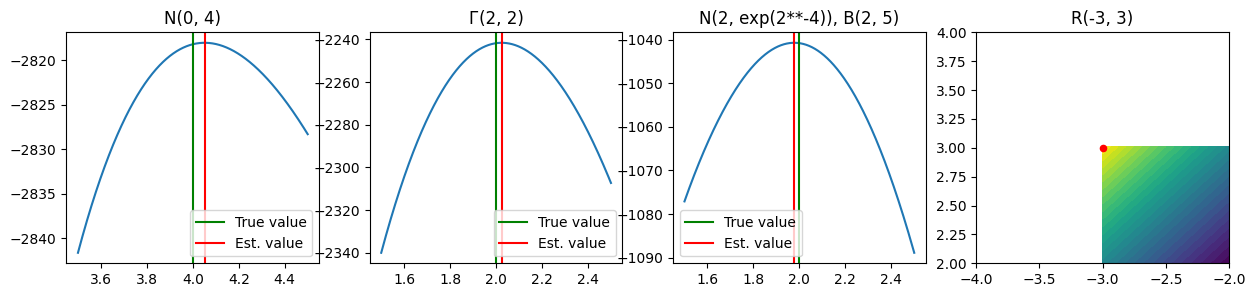

In [5]:
norm_likelihood = lambda s: np.sum(stats.norm.logpdf(norm_sample, 0, s))
s_vals = np.linspace(s-0.5, s+0.5, N)
norm_lh_vals = np.array([norm_likelihood(s) for s in s_vals])
s_est = s_vals[np.argmax(norm_lh_vals)]

plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
plt.plot(s_vals, norm_lh_vals)
plt.axvline(x=s, color='g', label = 'True value')
plt.axvline(x=s_est, color='r', label = 'Est. value')
plt.legend()
plt.title(f'N(0, {s})')

gamma_likelihood = lambda a: np.sum(stats.gamma.logpdf(gamma_sample, a, scale=2))
a_vals = np.linspace(alpha-0.5, alpha+0.5, N)
gamma_lh_vals = np.array([gamma_likelihood(a) for a in a_vals])
alpha_est = a_vals[np.argmax(gamma_lh_vals)]

plt.subplot(1, 4, 2)
plt.plot(a_vals, gamma_lh_vals)
plt.axvline(x=alpha, color='g', label = 'True value')
plt.axvline(x=alpha_est, color='r', label = 'Est. value')
plt.legend()
plt.title(f'Г({alpha}, 2)')

mix_likelihood = lambda t: np.sum(np.log(0.5 * stats.norm.pdf(mix_sample, t, np.exp(t**(-4))) + 0.5 * stats.beta.pdf(mix_sample, 2, 5)))
t_vals = np.linspace(t-0.5, t+0.5, N)
mix_lh_vals = np.array([mix_likelihood(t) for t in t_vals])
t_est = t_vals[np.argmax(mix_lh_vals)]

plt.subplot(1, 4, 3)
plt.plot(t_vals, mix_lh_vals)
plt.axvline(x=t, color='g', label = 'True value')
plt.axvline(x=t_est, color='r', label = 'Est. value')
plt.legend()
plt.title(f'N({t}, exp({t}**-4)), B(2, 5)')

def uni_likelihood(a, b):
    if a <= np.min(uni_sample) and b >= np.max(uni_sample):
        return -len(uni_sample) * np.log(b - a)
    else:
        return np.nan

a_vals = np.linspace(-4, -2, 500)
b_vals =  np.linspace(2, 4, 500)
A, B = np.meshgrid(a_vals, b_vals)
uni_lh_vals = np.zeros((500, 500))

for i in range(len(a_vals)):
    for j in range(len(b_vals)):
        uni_lh_vals[i, j] = uni_likelihood(a_vals[i], b_vals[j])

plt.subplot(1, 4, 4)
plt.contourf(A, B, uni_lh_vals, levels = 30)
plt.scatter(a, b, s = 20, c='r')
plt.title(f'R({a}, {b})')

**Вопрос:** Всегда ли функция правдоподобия имеет один глобальный максимум, или бывает несколько локальных максимумов?

Бывает несколько локальных максимумов, но для наших распределений логарифм функции правдоподобия вогнут и имеет один максимум, так как мы реализовывали стандартные распределения, а в смеси параметр участвовал только в одном из распределений.

Визуализируйте выборки, добавьте на график истинную плотность распределения и плотность распределения с оцененными параметрами

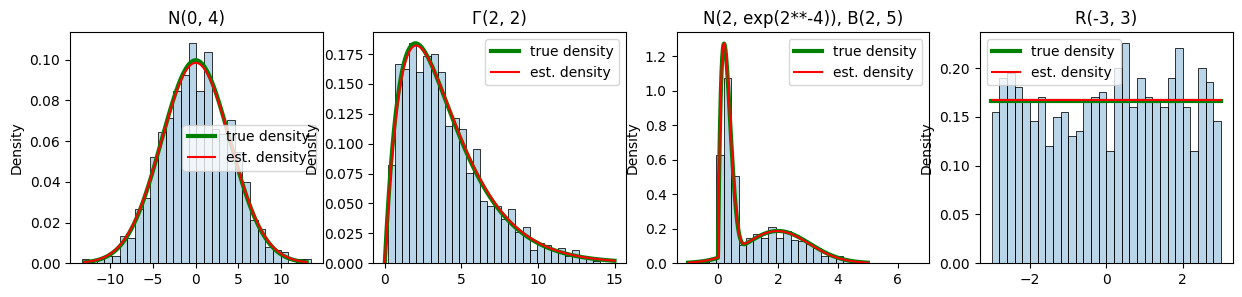

In [6]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
sb.histplot(norm_sample, bins=30, stat='density', alpha=0.3)

x_plot = np.linspace(-13, 13, N)
norm_pdf_true = stats.norm.pdf(x_plot, loc=0, scale=s)
norm_pdf_est = stats.norm.pdf(x_plot, loc=0, scale=s_est)

plt.plot(x_plot, norm_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, norm_pdf_est, color="r", label='est. density')
plt.title(f'N(0, {s})')
plt.legend()


plt.subplot(1, 4, 2)
sb.histplot(gamma_sample, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(0, 15, N)
gamma_pdf_true = stats.gamma.pdf(x_plot, alpha, scale=2)
gamma_pdf_est = stats.gamma.pdf(x_plot, alpha_est, scale=2)
plt.plot(x_plot, gamma_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, gamma_pdf_est, color="r", label='est. density')
plt.title(f'Г({alpha}, 2)')
plt.legend()

plt.subplot(1, 4, 3)
sb.histplot(mix_sample, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(-1, 5, N)
mix_pdf_true = 0.5 * stats.norm.pdf(x_plot, t, np.exp(t**(-4))) + 0.5 * stats.beta.pdf(x_plot, 2, 5)
mix_pdf_est = 0.5 * stats.norm.pdf(x_plot, t_est, np.exp(t_est**(-4))) + 0.5 * stats.beta.pdf(x_plot, 2, 5)
plt.plot(x_plot, mix_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, mix_pdf_est, color="r", label='est. density')
plt.title(f'N({t}, exp({t}**-4)), B(2, 5)')
plt.legend()

plt.subplot(1, 4, 4)
sb.histplot(uni_sample, bins=30, stat='density', alpha=0.3)

x_true = np.linspace(-3, 3, N)
uni_pdf_true = stats.uniform.pdf(x_true, loc=a, scale=b-a)
a_est = np.min(uni_sample)
b_est = np.max(uni_sample)
x_est = np.linspace(a_est, b_est, N)
uni_pdf_est = stats.uniform.pdf(x_est, loc=a_est, scale=b_est - a_est)

plt.plot(x_true, uni_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_est, uni_pdf_est, color="r", label='est. density')
plt.title(f'R({a}, {b})')
plt.legend()

**Вопрос:** Насколько оцененная плотность отличается от истинной? Подумайте, почему? Как меняется ОМП от количества элементов выборки?

Так как размер выборки сравнительно большой (N = 1000), то плотности отличаются не сильно. Большой размер выборки влияет на функцию правдоподобия, её максимум приближается к истинному значению параметра.

## Задача 3

Сгенерируйте выборки с самостоятельно заданными параметрами для следующих распределений:

1. $\mathcal{N}(\mu, 9)$
2. $Beta(a, 5)$
3. $\text{Г}(5,\beta)$
3. $Beta(\alpha, \beta)$


In [7]:
mu = 3
norm_sample = np.random.normal(mu, 9, N)

a = 3
beta_sample_1 = np.random.beta(a, 5, size=N)

beta_g = 2
gamma_sample = np.random.gamma(5, beta_g, size=N)

alpha = 5
beta_b = 3
beta_sample_2 = np.random.beta(alpha, beta_b, size=N)

Постройте для каждой выборки функцию спейсинга (или ее логарифм), визуально найдите на ней максимум, сравните его с численным решением и отметьте его на графике

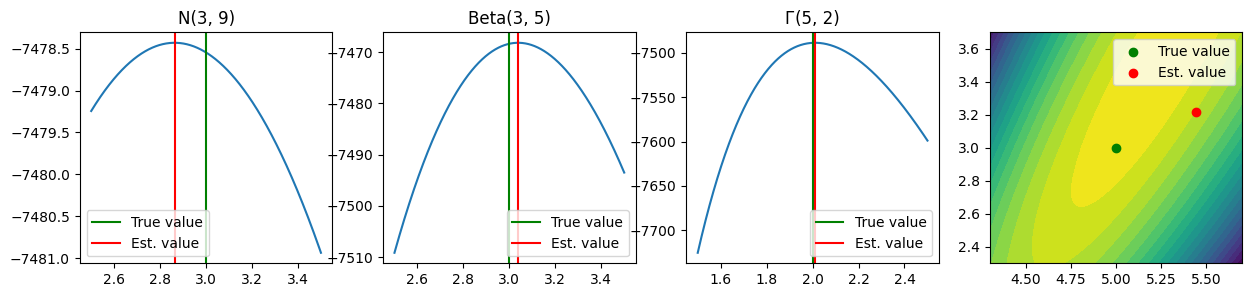

In [8]:
from scipy import optimize

def spacing(distribution, data, params):
    data_sorted = np.sort(data)
    cdf = distribution.cdf(data_sorted, *params)
    spacings = np.diff(cdf)
    return np.sum(np.log(spacings[spacings>0]))

mu_vals = np.linspace(mu-0.5, mu+0.5, N)
norm_spacing_vals = [spacing(stats.norm, norm_sample, [mu, 9]) for mu in mu_vals]
mu_est = mu_vals[np.argmax(norm_spacing_vals)]

plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
plt.plot(mu_vals, norm_spacing_vals)
plt.axvline(x=mu, color='g', label = 'True value')
plt.axvline(x=mu_est, color='r', label = 'Est. value')
plt.legend()
plt.title(f'N({mu}, {9})')

a_vals = np.linspace(a-0.5, a+0.5, N)
beta_1_spacing_vals = [spacing(stats.beta, beta_sample_1, [a, 5]) for a in a_vals]
a_est = a_vals[np.argmax(beta_1_spacing_vals)]

plt.subplot(1, 4, 2)
plt.plot(a_vals, beta_1_spacing_vals)
plt.axvline(x=a, color='g', label = 'True value')
plt.axvline(x=a_est, color='r', label = 'Est. value')
plt.legend()
plt.title(f'Beta({a}, {5})')

def gamma_spacing(a, b):
    data_sorted = np.sort(gamma_sample)
    cdf = stats.gamma.cdf(data_sorted, a, scale=b)
    spacings = np.diff(cdf)
    return np.sum(np.log(spacings[spacings>0]))

beta_g_vals = np.linspace(beta_g-0.5, beta_g+0.5, N)
gamma_spacing_vals = [gamma_spacing(5, b) for b in beta_g_vals]
beta_g_est = beta_g_vals[np.argmax(gamma_spacing_vals)]

plt.subplot(1, 4, 3)
plt.plot(beta_g_vals, gamma_spacing_vals)
plt.axvline(x=beta_g, color='g', label = 'True value')
plt.axvline(x=beta_g_est, color='r', label = 'Est. value')
plt.legend()
plt.title(f'Г({5}, {beta_g})')

n = 50
alpha_vals = np.linspace(alpha-0.7, alpha+0.7, n)
beta_b_vals = np.linspace(beta_b-0.7, beta_b+0.7, n)
A, B = np.meshgrid(alpha_vals, beta_b_vals)

beta_2_spacing_vals = np.zeros((n, n))
max = -1e10
for i in range(n):
    for j in range(n):
        beta_2_spacing_vals[i, j] = spacing(stats.beta, beta_sample_2, [alpha_vals[i], beta_b_vals[j]])
        if beta_2_spacing_vals[i, j] > max:
            alpha_est = alpha_vals[i]
            beta_b_est = beta_b_vals[j]
            max = beta_2_spacing_vals[i, j]

def beta_spacing(params):
    return -spacing(stats.beta, beta_sample_2, params)

res = optimize.minimize(beta_spacing, x0=[5, 3])

plt.subplot(1, 4, 4)
plt.contourf(A, B, beta_2_spacing_vals, levels=20)
plt.scatter(alpha, beta_b, c='g', label='True value')
plt.scatter(alpha_est, beta_b_est, c='r', label='Est. value')
plt.legend()

**Вопрос:** Всегда ли функция спейсинга имеет один глобальный максимум, или бывает несколько локальных максимумов?

Бывает несколько локальных максимумов, но в нашем случе все функции имеют один глобальный максимум.

Постройте гистограмму с оценкой плотности для каждой выборки, отметьте на графике матожидание и выборочные среднее и их погрешность с помощью среднеквадратичного и стандартного отклонений соответственно

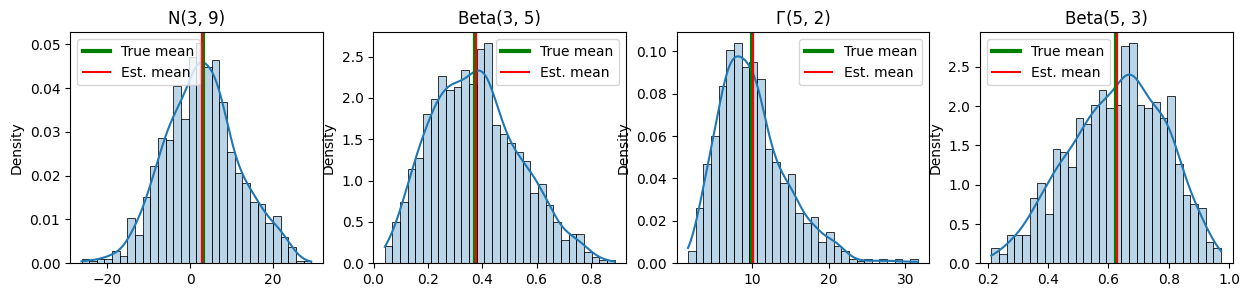

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
sb.histplot(norm_sample, bins=30, kde=True, stat='density', alpha=0.3, ax=ax[0])
mean = np.mean(norm_sample)
ax[0].axvline(x=mu, c='g', label='True mean', linewidth=3)
ax[0].axvline(x=mean, c='r', label='Est. mean')
ax[0].set_title(f'N({mu}, 9)')
ax[0].legend()

sb.histplot(beta_sample_1, bins=30, kde=True, stat='density', alpha=0.3, ax=ax[1])
mean = np.mean(beta_sample_1)
ax[1].axvline(x=a/(a+5), c='g', label='True mean', linewidth=3)
ax[1].axvline(x=mean, c='r', label='Est. mean')
ax[1].set_title(f'Beta({a}, 5)')
ax[1].legend()

sb.histplot(gamma_sample, bins=30, kde=True, stat='density', alpha=0.3, ax=ax[2])
mean = np.mean(gamma_sample)
ax[2].axvline(x=5*beta_g, c='g', label='True mean', linewidth=3)
ax[2].axvline(x=mean, c='r', label='Est. mean')
ax[2].set_title(f'Г(5, {beta_g})')
ax[2].legend()

sb.histplot(beta_sample_2, bins=30, kde=True, stat='density', alpha=0.3, ax=ax[3])
mean = np.mean(beta_sample_2)
ax[3].axvline(x=alpha/(alpha+beta_b), c='g', label='True mean', linewidth=3)
ax[3].axvline(x=mean, c='r', label='Est. mean')
ax[3].set_title(f'Beta({alpha}, {beta_b})')
ax[3].legend()

Визуализируйте выборки, добавьте на график истинную плотность распределения и плотность распределения с оцененными параметрами

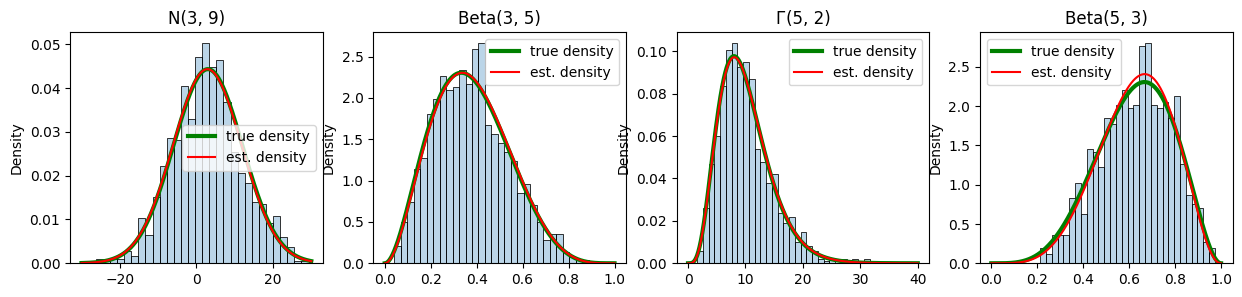

In [10]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
sb.histplot(norm_sample, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(-30, 30, N)
norm_pdf_true = stats.norm.pdf(x_plot, mu, scale=9)
norm_pdf_est = stats.norm.pdf(x_plot, mu_est, scale=9)
plt.plot(x_plot, norm_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, norm_pdf_est, color="r", label='est. density')
plt.title(f'N({mu}, 9)')
plt.legend()

plt.subplot(1, 4, 2)
sb.histplot(beta_sample_1, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(0, 1, N)
beta_pdf_true = stats.beta.pdf(x_plot, a, 5)
beta_pdf_est = stats.beta.pdf(x_plot, a_est, 5)
plt.plot(x_plot, beta_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, beta_pdf_est, color="r", label='est. density')
plt.title(f'Beta({a}, 5)')
plt.legend()

plt.subplot(1, 4, 3)
sb.histplot(gamma_sample, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(0, 40, N)
gamma_pdf_true = stats.gamma.pdf(x_plot, 5, scale=beta_g)
gamma_pdf_est = stats.gamma.pdf(x_plot, 5, scale=beta_g_est)
plt.plot(x_plot, gamma_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, gamma_pdf_est, color="r", label='est. density')
plt.title(f'Г(5, {beta_g})')
plt.legend()

plt.subplot(1, 4, 4)
sb.histplot(beta_sample_2, bins=30, stat='density', alpha=0.3)
x_plot = np.linspace(0, 1, N)
beta_pdf_true = stats.beta.pdf(x_plot, alpha, beta_b)
beta_pdf_est = stats.beta.pdf(x_plot, alpha_est, beta_b_est)
plt.plot(x_plot, beta_pdf_true, color="g", label='true density', linewidth=3)
plt.plot(x_plot, beta_pdf_est, color="r", label='est. density')
plt.title(f'Beta({alpha}, {beta_b})')
plt.legend()

**Вопрос:** Насколько оцененная плотность отличается от истинной? Подумайте, почему? Как меняется ОМС от количества элементов выборки?

Так как размер выборки сравнительно большой (N = 1000), то плотности отличаются не сильно. Большой размер выборки влияет на функцию спейсингов, её максимум приближается к истинному значению параметра.

## Задача 4

В файле *poisson.txt* приведено количество ясных дней зимой для 115 городов России. Из физики погоды известно, что такое данные хорошо приближаются Пуассоновским распределением

Загрузите датасет, визуализируйте выборку

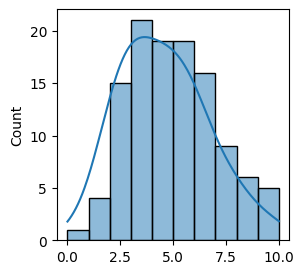

In [11]:
with open('poisson.txt', 'r') as f:
    data = [int(line.strip()) for line in f.readlines()]

data = np.array(data)
plt.figure(figsize=(3, 3))
sb.histplot(data, kde=True, bins=10)
plt.show()

Постройте оценку для наиболее ожидаемого числа ясных дней понравившимся вам способом

In [12]:
l_est = np.mean(data)
l_est

np.float64(4.539130434782609)

Добавьте на график выборки плотность распределения с оцененным параметром и значение наиболее ожидаемого числа ясных дней

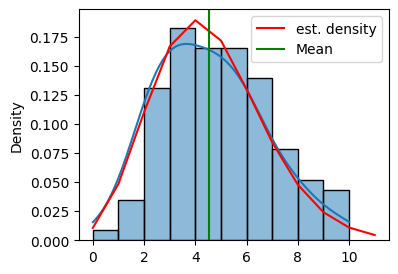

In [13]:
plt.figure(figsize=(4, 3))
sb.histplot(data, kde=True, bins=10, stat='density')
x_plot = np.arange(0, 12)
plt.plot(x_plot, stats.poisson.pmf(x_plot, l_est), c='r', label="est. density")
plt.axvline(l_est, c='g', label='Mean')
plt.legend()
plt.show()

**Вопрос:** Объясните полученный результат и обоснуйте выбор метода

Видно, что плотность выборки и оценочная плотность близки, использовался метод ОММ, так как из выборки сразу следует оценка на значение параметра - просто среднее выборки.